# Exploratory Data Analysis — Anti-Bunching Copilot

**COMPX523-26A Assignment 3 · SUNT (Salvador) · bus-bunching, driver-facing**

This notebook **characterises the data** behind `pipeline_walkthrough.ipynb` so you can judge which streaming model fits. It is **self-contained** (direct pandas; it only reads `config.yaml` for the scope/paths) and presents **neutral findings** — it does *not* recommend a model. The modelling decision stays in `pipeline_walkthrough.ipynb`.

- **Section A — raw OD data:** trajectories, headways, crowding, data quality (justifies the feature engineering).
- **Section B — processed feature/label table:** distributions, class balance, feature↔label, non-stationarity hints (the evidence that informs model choice).

Run in the project venv (Python 3.12). EDA needs only pandas/numpy/matplotlib. If `data/processed/features.csv` is missing, run `python prepare_data.py` first.

## 0. Setup

In [1]:
from pathlib import Path
import numpy as np, pandas as pd, yaml
import matplotlib.pyplot as plt

pd.set_option('display.width', 120)
plt.rcParams['figure.dpi'] = 110

ROOT = Path.cwd()
cfg = yaml.safe_load(open(ROOT / 'config.yaml'))
OD_DIR = (ROOT / cfg['paths']['od_dir']).resolve()
scope = cfg['scope']
ROUTES = [str(r) for r in scope['routes']]
DIRS = [str(d) for d in scope['directions']]
print('OD dir :', OD_DIR)
print('scope  :', ROUTES, DIRS, scope['start_date'], '..', scope['end_date'])

OD dir : /Users/ademartutor/Documents/UoW/Trimester A - 2026/COMPX523 - Machine Learning for Data Streams/Assignment 3/Dataset/SUNT/data/od
scope  : ['1007', '1386', '1346', '1649'] ['I', 'V'] 2024-03-01 .. 2024-03-03


---
# Section A — Raw OD data

## A1. Load the scoped OD parquet

Each OD row is *one bus arriving at one stop* with a timestamp and crowding. Note the boarding/alighting columns are **hyphenated** (`n-boardings`, `n-alighting`). `direction_id` is `I`/`V` (one-way / return).

In [2]:
def daterange(a, b):
    from datetime import date, timedelta
    d0, d1 = date.fromisoformat(a), date.fromisoformat(b)
    out, d = [], d0
    while d <= d1:
        out.append(d.isoformat()); d += timedelta(days=1)
    return out

frames = []
for ds in daterange(scope['start_date'], scope['end_date']):
    fp = OD_DIR / f'od-{ds}.parquet'
    if fp.exists():
        d = pd.read_parquet(fp)
        d = d[d['route_short_name'].astype(str).isin(ROUTES) & d['direction_id'].astype(str).isin(DIRS)]
        frames.append(d)
od = pd.concat(frames, ignore_index=True)
od['stop_time'] = pd.to_datetime(od['stop_time'], errors='coerce')
for c in ['route_short_name','direction_id','vehicle','trip_id']:
    od[c] = od[c].astype(str)
print('shape:', od.shape)
print('span :', od['stop_time'].min(), '->', od['stop_time'].max())
print('distinct  vehicles:', od.vehicle.nunique(), '| routes:', od.route_short_name.nunique(), '| trips:', od.trip_id.nunique())
print('columns:', list(od.columns))
od.head(4)

shape: (100646, 16)
span : 2024-03-01 03:59:51 -> 2024-03-04 01:27:17
distinct  vehicles: 257 | routes: 4 | trips: 1317
columns: ['route_short_name', 'register_code', 'direction_id', 'pt_sequence', 'stop_id', 'vehicle', 'trip_number', 'trip_id', 'start_trip', 'end_trip', 'stop_time', 'n-boardings', 'n-alighting', 'lag_loading', 'balance', 'loading']


,route_short_name,register_code,direction_id,pt_sequence,stop_id,vehicle,trip_number,trip_id,start_trip,end_trip,stop_time,n-boardings,n-alighting,lag_loading,balance,loading
0,1386,12550,I,1,45834097,20431,1,20431_1386_1,2024-03-01 05:48:06,2024-03-01 07:22:11,2024-03-01 05:48:06,2.157993,0.0,0.000000,0.000000,2.157993
1,1386,12550,I,2,44782442,20431,1,20431_1386_1,2024-03-01 05:48:06,2024-03-01 07:22:11,2024-03-01 05:48:20,4.315987,0.0,2.157993,2.157993,6.473979
2,1386,12550,I,3,47566681,20431,1,20431_1386_1,2024-03-01 05:48:06,2024-03-01 07:22:11,2024-03-01 05:49:30,0.000000,0.0,6.473979,6.473979,6.473979
3,1386,12550,I,4,44783270,20431,1,20431_1386_1,2024-03-01 05:48:06,2024-03-01 07:22:11,2024-03-01 05:50:09,0.000000,0.0,6.473979,6.473979,6.473979


## A2. Data quality

Three checks that justify the experiment's preprocessing: missing values, **non-monotonic `stop_time`** trips (a bus's stop timestamps must increase along the route), and the share of NaN/edge cases. The experiment drops the non-monotonic trips.

In [3]:
print('missing values per column:')
print(od.isna().sum()[od.isna().sum() > 0] if od.isna().sum().sum() else '  (none)')

# non-monotonic stop_time trips
def is_monotonic(g):
    st = g.sort_values('pt_sequence')['stop_time'].values
    return len(st) >= 2 and np.all(np.diff(st).astype('timedelta64[s]').astype(float) >= 0)

mono = od.groupby('trip_id').apply(is_monotonic)
print(f"\ntrips total: {mono.size} | non-monotonic: {(~mono).sum()} ({(~mono).mean():.1%})")
print('stops per trip (describe):')
print(od.groupby('trip_id').size().describe()[['min','50%','mean','max']].round(1).to_dict())

missing values per column:
  (none)

trips total: 1317 | non-monotonic: 335 (25.4%)
stops per trip (describe):
{'min': 47.0, '50%': 65.0, 'mean': 76.4, 'max': 246.0}


/tmp/claude-501/ipykernel_70961/4122924062.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mono = od.groupby('trip_id').apply(is_monotonic)


## A3. Per-bus trajectory & a string diagram

**Left:** one example trip — stop sequence and onboard `loading` vs time (load builds up, then empties toward the end of the route). **Right:** a *string diagram* for one route×direction — each line is one bus; lines **converging** is exactly bunching.

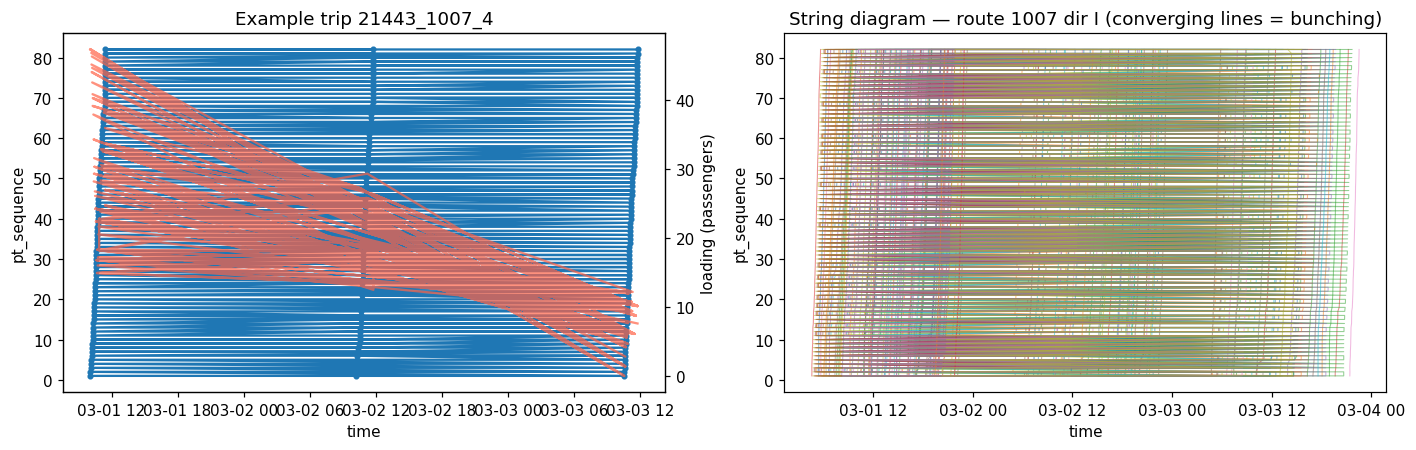

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))

# example trip
tid = od.groupby('trip_id').size().sort_values().index[-1]  # a long trip
g = od[od['trip_id'] == tid].sort_values('pt_sequence')
ax[0].plot(g['stop_time'], g['pt_sequence'], '-o', ms=3, label='stop sequence')
ax2 = ax[0].twinx()
ax2.plot(g['stop_time'], g['loading'], color='tomato', alpha=.7, label='loading')
ax[0].set_title(f'Example trip {tid}'); ax[0].set_xlabel('time'); ax[0].set_ylabel('pt_sequence')
ax2.set_ylabel('loading (passengers)')

# string diagram
r, dd = ROUTES[0], DIRS[0]
sub = od[(od.route_short_name == r) & (od.direction_id == dd)]
for _t, gg in sub.groupby('trip_id'):
    gg = gg.sort_values('pt_sequence')
    ax[1].plot(gg['stop_time'], gg['pt_sequence'], lw=.7, alpha=.5)
ax[1].set_title(f'String diagram — route {r} dir {dd} (converging lines = bunching)')
ax[1].set_xlabel('time'); ax[1].set_ylabel('pt_sequence')
fig.tight_layout(); plt.show()

## A4. Forward headway — the core signal

Forward headway = at a stop (for one route+direction), minutes since the **previous distinct vehicle** arrived. This is the quantity bunching is defined on (and the quantity the 5-/30-min aggregate would destroy). We expect a wide spread — tight gaps when bunched, long gaps in service holes — and a time-of-day pattern.

headway (min) describe: {'min': 0.5, '25%': 6.4, '50%': 14.5, '75%': 26.5, 'max': 90.8}


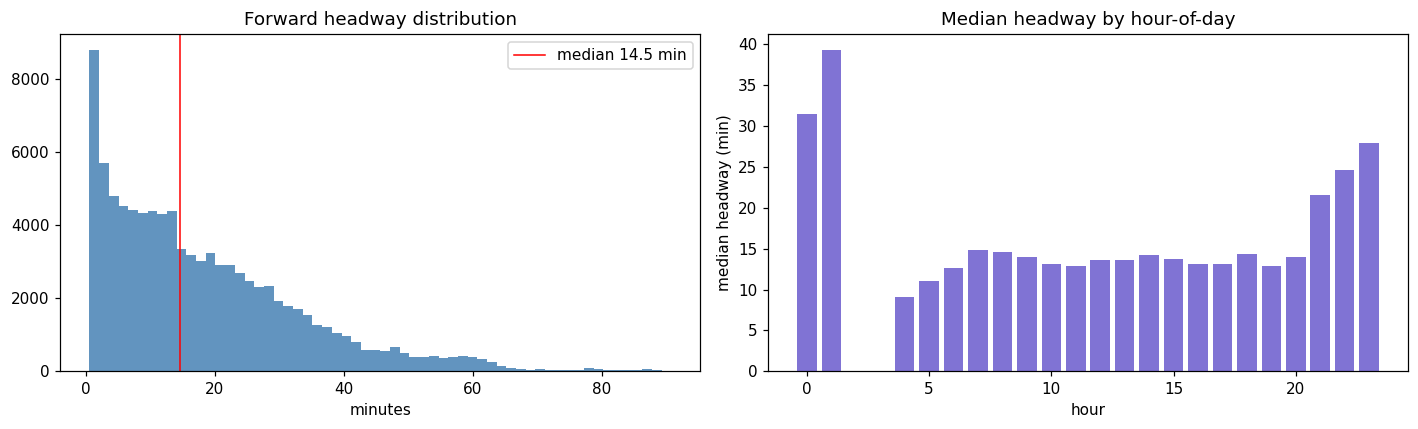

In [5]:
key = ['route_short_name', 'direction_id', 'stop_id']
od = od.sort_values(key + ['stop_time'])
od['headway_min'] = (od['stop_time'] - od.groupby(key)['stop_time'].shift(1)).dt.total_seconds() / 60
hw = od['headway_min'].dropna()
hw = hw[(hw > 0.5) & (hw < 120)]  # drop artefacts / overnight gaps for the view
print('headway (min) describe:', hw.describe()[['min','25%','50%','75%','max']].round(1).to_dict())

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(hw, bins=60, color='steelblue', alpha=.85)
ax[0].axvline(hw.median(), color='red', lw=1, label=f'median {hw.median():.1f} min')
ax[0].set_title('Forward headway distribution'); ax[0].set_xlabel('minutes'); ax[0].legend()

od['hr'] = od['stop_time'].dt.hour
byhr = od[od['headway_min'].between(0.5, 120)].groupby('hr')['headway_min'].median()
ax[1].bar(byhr.index, byhr.values, color='slateblue', alpha=.85)
ax[1].set_title('Median headway by hour-of-day'); ax[1].set_xlabel('hour'); ax[1].set_ylabel('median headway (min)')
fig.tight_layout(); plt.show()

## A5. Crowding (`loading`)

Onboard load distribution, how it varies by hour, and the characteristic build-up-then-empty shape along the route (`pt_sequence`).

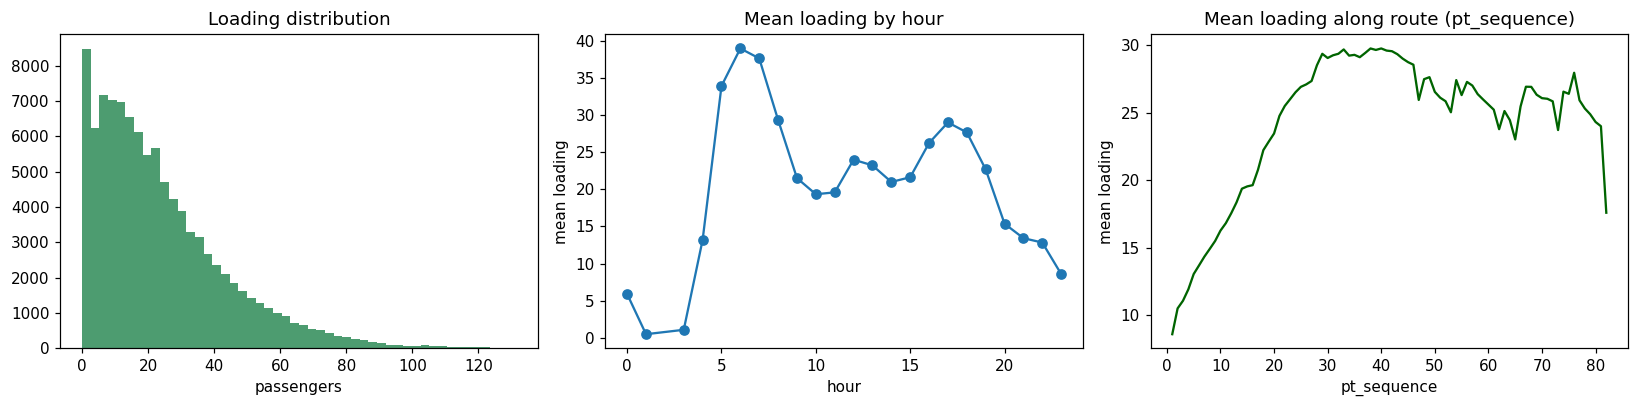

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].hist(od['loading'].dropna(), bins=50, color='seagreen', alpha=.85)
ax[0].set_title('Loading distribution'); ax[0].set_xlabel('passengers')

od.groupby('hr')['loading'].mean().plot(ax=ax[1], marker='o')
ax[1].set_title('Mean loading by hour'); ax[1].set_xlabel('hour'); ax[1].set_ylabel('mean loading')

prof = od.groupby('pt_sequence')['loading'].mean()
ax[2].plot(prof.index, prof.values, color='darkgreen')
ax[2].set_title('Mean loading along route (pt_sequence)'); ax[2].set_xlabel('pt_sequence'); ax[2].set_ylabel('mean loading')
fig.tight_layout(); plt.show()

---
# Section B — Processed feature/label table

This is the table the model actually consumes (`data/processed/features.csv`, produced by `prepare_data.py`): 10 causal features + the 3-class bunching label. The analysis below is what most directly informs model choice.

In [7]:
proc_path = ROOT / cfg['paths']['processed']
assert proc_path.exists(), f'Missing {proc_path} — run `python prepare_data.py` first.'
df = pd.read_csv(proc_path, parse_dates=['stop_time'])
FEATS = ['headway_min','headway_ratio','headway_trend','since_prev_stop_min','loading',
         'recent_boardings','pt_sequence','minute_of_day','dow','is_peak']
LAB = {0:'ok', 1:'warning', 2:'bunching'}
print('shape:', df.shape)
df[FEATS + ['label']].describe().T[['mean','std','min','50%','max']].round(2)

shape: (55759, 18)


,mean,std,min,50%,max
headway_min,36.67,74.38,0.50,20.10,824.62
headway_ratio,1.71,2.74,0.01,1.05,50.39
headway_trend,0.84,97.94,-791.40,0.00,782.43
since_prev_stop_min,1.20,1.35,0.00,0.97,76.23
loading,23.75,19.60,0.00,18.92,122.70
recent_boardings,3.23,5.85,0.00,1.13,93.23
pt_sequence,32.07,19.71,1.00,31.00,82.00
minute_of_day,863.35,310.48,0.00,879.00,1439.00
dow,4.74,0.81,0.00,5.00,6.00
is_peak,0.35,0.48,0.00,0.00,1.00


## B1. Class balance

The target is imbalanced — 'bunching' is a minority class. This is why the experiment reports **recall/F1 on the bunching class** (not headline accuracy): a model that always predicts 'ok' would look deceptively good on accuracy alone.

{'ok': '69.0%', 'warning': '9.6%', 'bunching': '21.5%'}


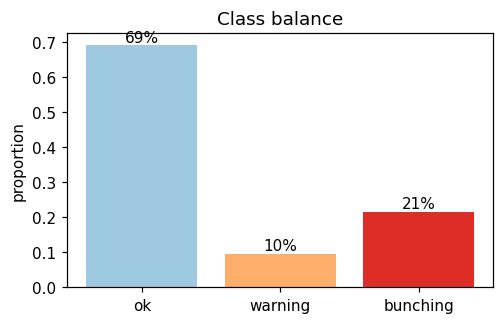

In [8]:
bal = df['label'].value_counts(normalize=True).sort_index()
print({LAB[k]: f'{v:.1%}' for k, v in bal.items()})
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar([LAB[i] for i in bal.index], bal.values, color=['#9ecae1','#fdae6b','#de2d26'])
ax.set_ylabel('proportion'); ax.set_title('Class balance')
for i, v in enumerate(bal.values):
    ax.text(i, v + .01, f'{v:.0%}', ha='center')
plt.show()

## B2. Feature distributions

Histograms of each feature. Watch for: heavy **skew** (e.g. `headway_ratio`, `recent_boardings`) — tree-based learners handle this without scaling, distance/linear models usually want a transform; and any **near-constant** feature (at a single-day scope `dow` is constant — effectively dead until you widen the date range).

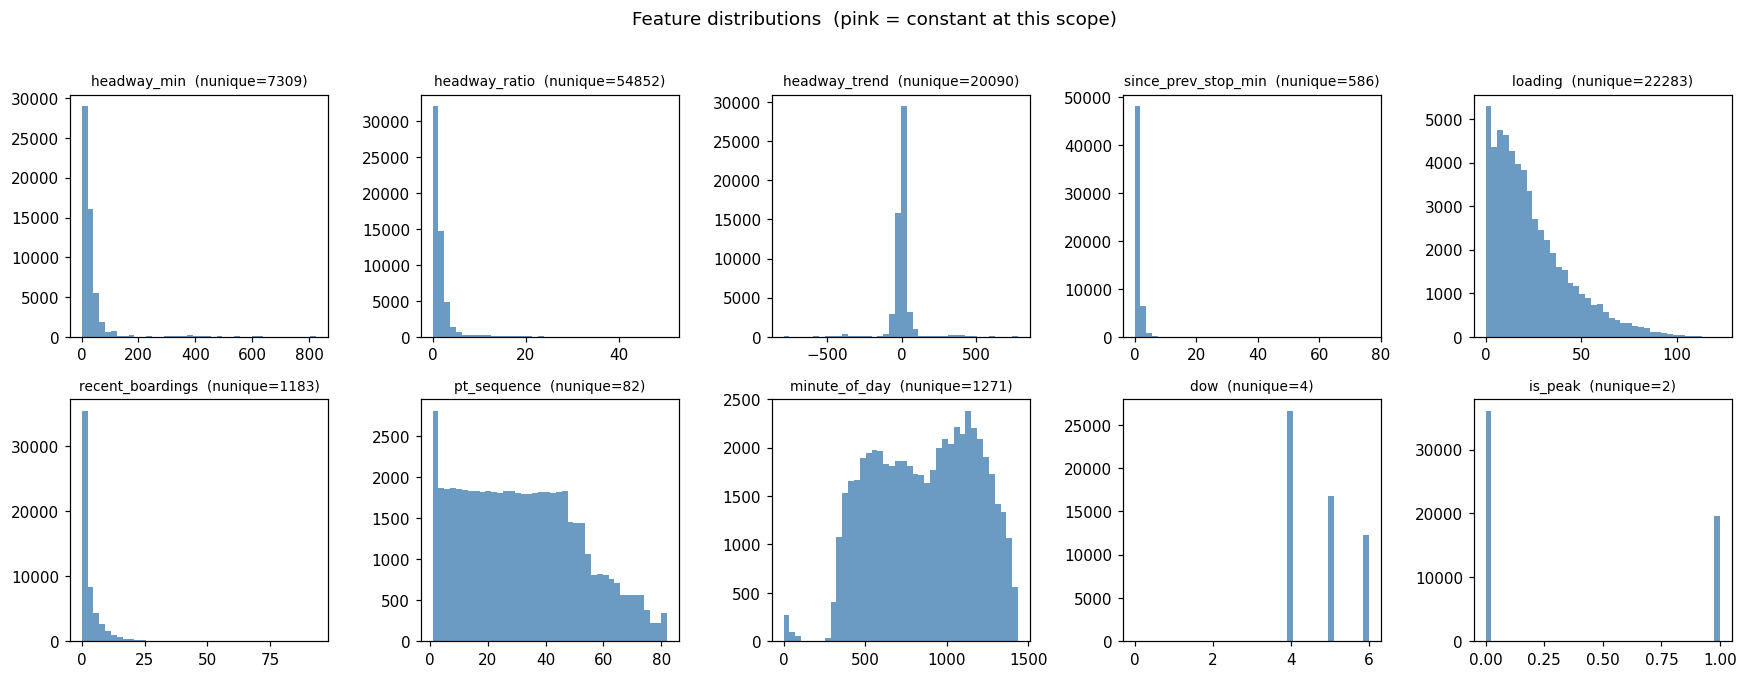

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for ax, f in zip(axes.ravel(), FEATS):
    vals = df[f].replace([np.inf, -np.inf], np.nan).dropna()
    ax.hist(vals, bins=40, color='steelblue', alpha=.8)
    nun = df[f].nunique()
    ax.set_title(f'{f}  (nunique={nun})', fontsize=9)
    if nun <= 1:
        ax.set_facecolor('#fff3f3')  # highlight a dead/constant feature
fig.suptitle('Feature distributions  (pink = constant at this scope)', y=1.02)
fig.tight_layout(); plt.show()

## B3. Feature ↔ label — which features separate bunching?

Box plots of each feature split by class. A feature whose 'bunching' box sits clearly apart from 'ok' carries signal. Headway-derived features (`headway_ratio`, `headway_min`, `headway_trend`) should separate the classes most.

/tmp/claude-501/ipykernel_70961/1808979240.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=['ok','warn','bunch'], showfliers=False)
/tmp/claude-501/ipykernel_70961/1808979240.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=['ok','warn','bunch'], showfliers=False)
/tmp/claude-501/ipykernel_70961/1808979240.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=['ok','warn','bunch'], showfliers=False)
/tmp/claude-501/ipykernel_70961/1808979240.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels'

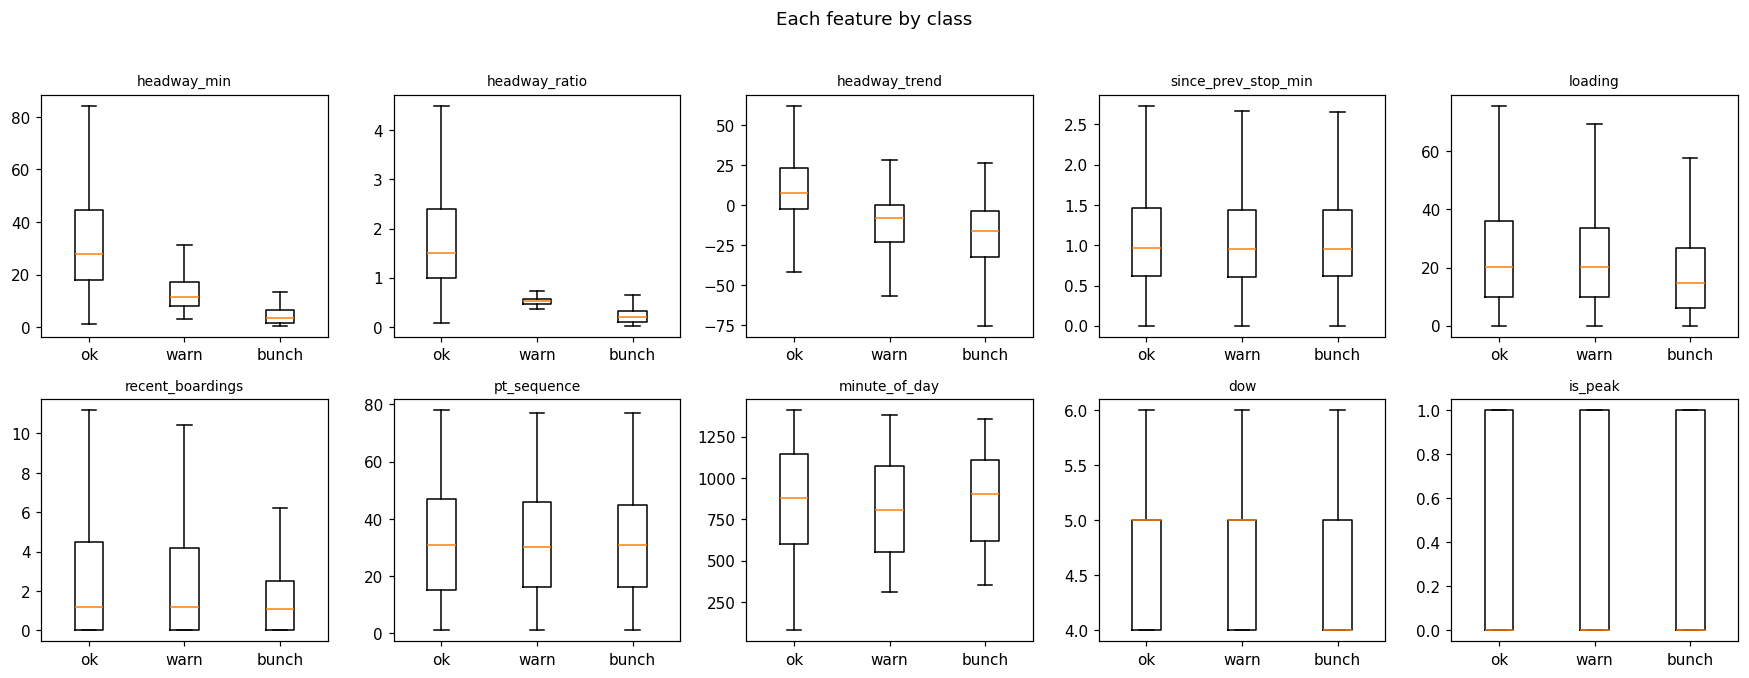

In [10]:
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for ax, f in zip(axes.ravel(), FEATS):
    data = [df[df.label == c][f].replace([np.inf,-np.inf], np.nan).dropna() for c in [0,1,2]]
    # clip extreme outliers for readability
    data = [d.clip(d.quantile(.01), d.quantile(.99)) for d in data]
    ax.boxplot(data, labels=['ok','warn','bunch'], showfliers=False)
    ax.set_title(f, fontsize=9)
fig.suptitle('Each feature by class', y=1.02); fig.tight_layout(); plt.show()

Quantify it: correlation heatmap between features, and the (point-biserial) correlation of each feature with a **bunching indicator** (label==2). Larger magnitude = more linearly informative about bunching.

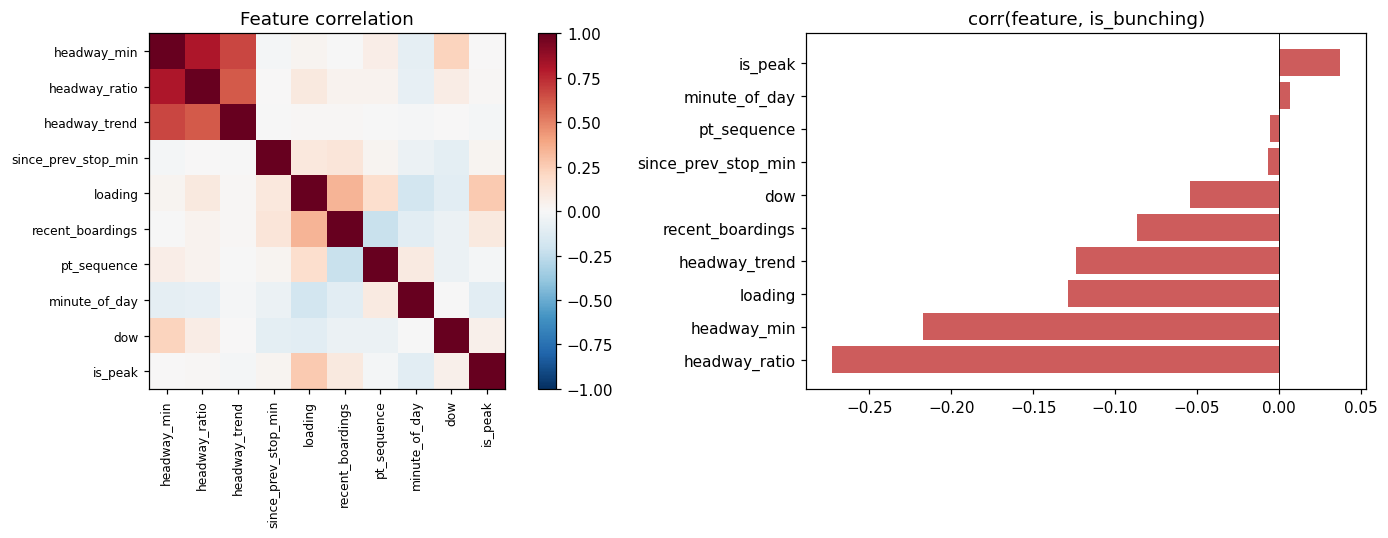

strongest (abs) correlations with bunching:
{'headway_ratio': -0.273, 'headway_min': -0.217, 'loading': -0.129, 'headway_trend': -0.124, 'recent_boardings': -0.087, 'dow': -0.054, 'is_peak': 0.037, 'minute_of_day': 0.007, 'since_prev_stop_min': -0.006, 'pt_sequence': -0.006}


In [11]:
X = df[FEATS].replace([np.inf,-np.inf], np.nan).fillna(0.0)
corr = X.corr()
fig, ax = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios':[1.2,1]})
im = ax[0].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax[0].set_xticks(range(len(FEATS))); ax[0].set_xticklabels(FEATS, rotation=90, fontsize=8)
ax[0].set_yticks(range(len(FEATS))); ax[0].set_yticklabels(FEATS, fontsize=8)
ax[0].set_title('Feature correlation'); fig.colorbar(im, ax=ax[0], fraction=.046)

y_bunch = (df['label'] == 2).astype(int)
pb = X.apply(lambda col: np.corrcoef(col, y_bunch)[0,1] if col.std()>0 else 0.0).sort_values()
ax[1].barh(pb.index, pb.values, color='indianred')
ax[1].set_title('corr(feature, is_bunching)'); ax[1].axvline(0, color='k', lw=.6)
fig.tight_layout(); plt.show()
print('strongest (abs) correlations with bunching:')
print(pb.reindex(pb.abs().sort_values(ascending=False).index).round(3).to_dict())

## B4. Class separability

Do the classes separate with a simple linear boundary, or do they overlap and interact (favouring non-linear learners)? A 2-D scatter on the two most informative features, plus a 2-component PCA coloured by class.

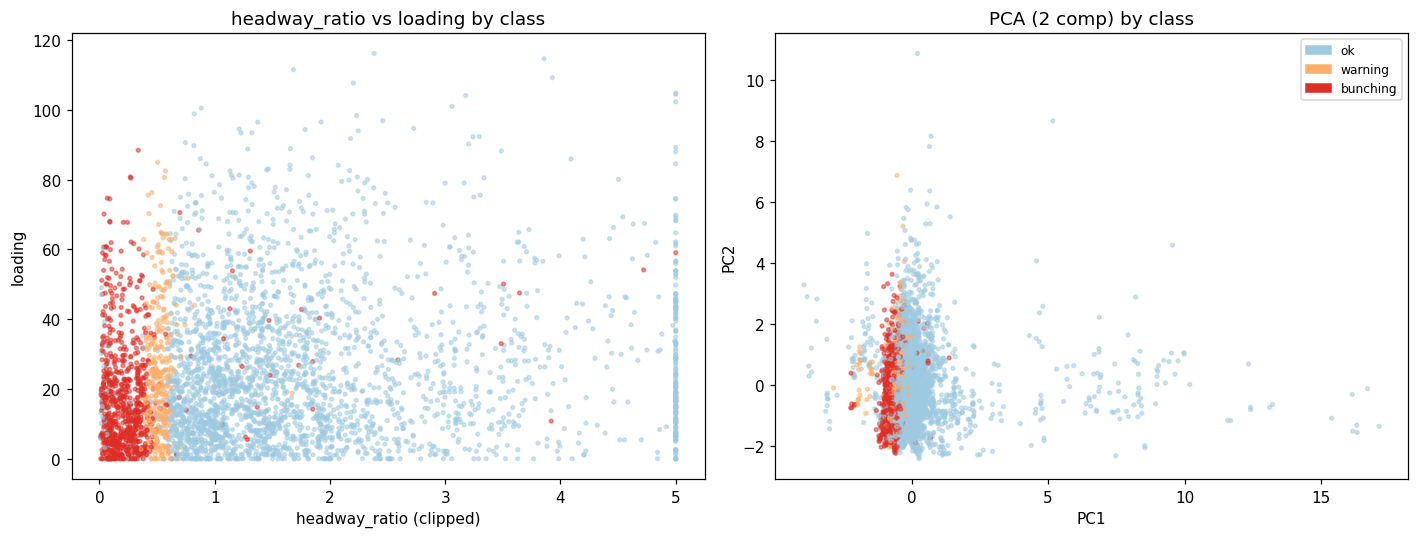

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

colors = np.array(['#9ecae1','#fdae6b','#de2d26'])
samp = df.sample(min(4000, len(df)), random_state=0)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].scatter(samp['headway_ratio'].clip(0,5), samp['loading'], c=colors[samp['label']], s=6, alpha=.5)
ax[0].set_xlabel('headway_ratio (clipped)'); ax[0].set_ylabel('loading')
ax[0].set_title('headway_ratio vs loading by class')

Z = PCA(n_components=2, random_state=0).fit_transform(StandardScaler().fit_transform(X.loc[samp.index]))
ax[1].scatter(Z[:,0], Z[:,1], c=colors[samp['label']], s=6, alpha=.5)
ax[1].set_title('PCA (2 comp) by class'); ax[1].set_xlabel('PC1'); ax[1].set_ylabel('PC2')
from matplotlib.patches import Patch
ax[1].legend(handles=[Patch(color=colors[i], label=LAB[i]) for i in [0,1,2]], fontsize=8)
fig.tight_layout(); plt.show()

## B5. Non-stationarity hints (why streaming / drift may matter)

Streaming models with drift adaptation pay off when the data distribution **moves over time**. Two views: bunching rate across the chronological stream, and rolling means of key features. *Caveat:* at the default single-day, 2-route scope there is limited room for genuine cross-day drift — widen the scope in `config.yaml` to probe this properly. Presented as observation, not a recommendation.

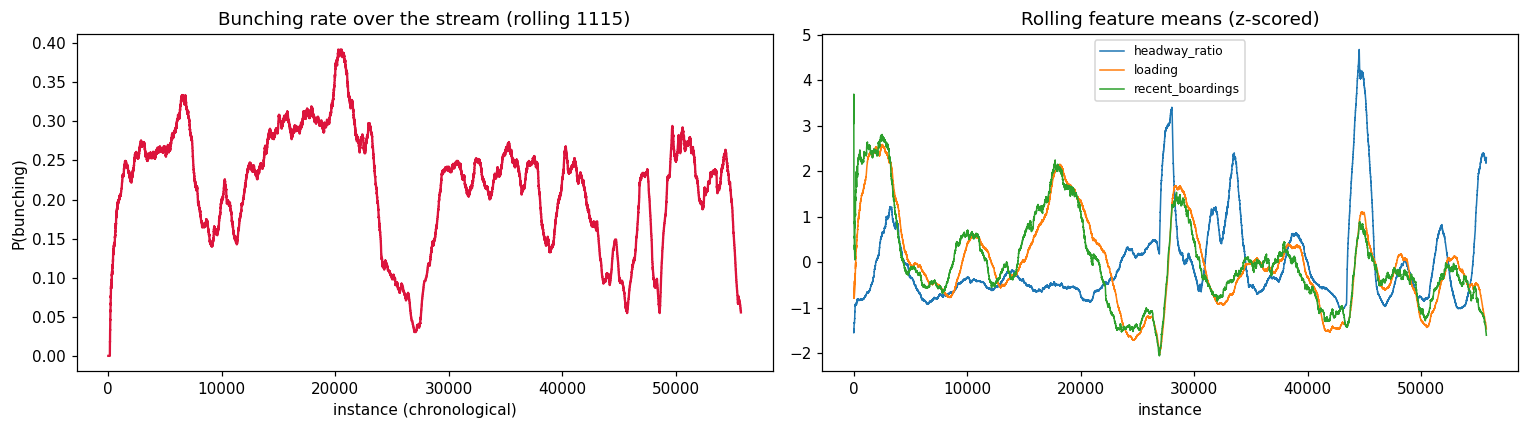

bunching rate by hour-of-day:
{0: 0.01, 1: 0.0, 4: 0.0, 5: 0.12, 6: 0.18, 7: 0.2, 8: 0.21, 9: 0.24, 10: 0.28, 11: 0.17, 12: 0.18, 13: 0.21, 14: 0.25, 15: 0.28, 16: 0.27, 17: 0.25, 18: 0.27, 19: 0.27, 20: 0.23, 21: 0.13, 22: 0.09, 23: 0.05}


In [13]:
d = df.sort_values('stop_time').reset_index(drop=True)
win = max(200, len(d)//50)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

roll_bunch = (d['label'] == 2).rolling(win, min_periods=20).mean()
ax[0].plot(roll_bunch.values, color='crimson')
ax[0].set_title(f'Bunching rate over the stream (rolling {win})')
ax[0].set_xlabel('instance (chronological)'); ax[0].set_ylabel('P(bunching)')

for f in ['headway_ratio','loading','recent_boardings']:
    s = d[f].replace([np.inf,-np.inf], np.nan).rolling(win, min_periods=20).mean()
    ax[1].plot((s - s.mean())/ (s.std()+1e-9), label=f, lw=1)
ax[1].set_title('Rolling feature means (z-scored)'); ax[1].set_xlabel('instance'); ax[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

print('bunching rate by hour-of-day:')
print((d.assign(hr=d.stop_time.dt.hour).groupby('hr')['label'].apply(lambda s:(s==2).mean())).round(2).to_dict())

## 12. Summary of findings (neutral)

What the data shows (observations only — the modelling choice is made in `pipeline_walkthrough.ipynb`):

- **Imbalanced target.** 'bunching' is a minority class → accuracy is misleading; recall/F1 on the bunching class are the meaningful metrics, and class imbalance is a factor any model must contend with.
- **Skewed, heavy-tailed features.** `headway_ratio`, `recent_boardings`, `headway_trend` are far from Gaussian → tree-based learners cope without scaling; distance/linear methods would need transforms/standardisation.
- **Headway features carry the signal.** The headway-derived features separate the bunching class most; crowding/position add secondary signal.
- **Overlapping, non-linear classes.** The 2-D / PCA views show the classes are not linearly separable and interact → flexible, non-linear decision boundaries are relevant.
- **Within-day variation in bunching rate.** Bunching probability changes with hour-of-day → time-of-day features matter; whether *cross-day* drift exists needs a wider scope.
- **Dead feature at single-day scope.** `dow` is constant when only one date is loaded — widen `config.yaml` dates to make it (and any real drift) informative.
- **Small-scope caveat.** Default = 2 routes / 1 day / ~21k instances. Findings are indicative; widen the scope before drawing firm conclusions.

These observations are the evidence to weigh when choosing and configuring the streaming model in `pipeline_walkthrough.ipynb`.